## Análisis Exploratorio de Datos (EDA) - Predicción del Abandono Escolar

Este proyecto realiza un análisis exploratorio de datos (EDA) sobre variables asociadas al rendimiento académico y abandono estudiantil.

Se aplican técnicas de limpieza, tratamiento de valores nulos, detección de valores atípicos y visualización de datos para identificar patrones relevantes.

**Objetivo**

Realizar un análisis exploratorio de datos para identificar patrones relacionados con el rendimiento académico y abandono estudiantil.

**Herramientas utilizadas**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

**Procesos realizados**
- Limpieza de datos
- Tratamiento de nulos
- Detección de outliers
- Análisis exploratorio
- Visualización de datos

**Principales hallazgos**
- La asistencia tiene una fuerte relación con el abandono escolar
- El estrés elevado afecta negativamente el rendimiento académico
- Más horas de estudio se relacionan con mejor rendimiento
- La mayoría de los estudiantes no abandonan, pero existe un grupo importante en riesgo
- El acceso a internet y factores socioeconómicos podrían influir en el desempeño

**Autor**

Wara López

**Introducción**

El presente proyecto desarrolla un análisis exploratorio de datos (EDA) sobre un conjunto de datos orientado a la predicción del abandono escolar.

El dataset simula un entorno académico realista para 10.000 estudiantes e incluye variables demográficas, académicas y conductuales relacionadas con el rendimiento estudiantil y el riesgo de abandono.

El objetivo principal es identificar patrones, relaciones y posibles factores asociados al abandono escolar mediante técnicas de limpieza, análisis estadístico y visualización de datos.

**Fuente de datos**

El conjunto de datos fue obtenido desde Kaggle y corresponde a un dataset sintético diseñado para proyectos de análisis educativo y predicción del abandono estudiantil.

Características del dataset:

- 10.000 registros
- 19 variables
- Variables numéricas y categóricas
- Valores faltantes simulados (~5%)
- Variable objetivo: Dropout

Variable objetivo:
- 0 = continúa
- 1 = abandono

**Importación de librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Carga del conjunto de datos**

In [2]:
df = pd.read_csv('student_dropout_dataset_v3.csv')

**Exploración inicial de datos**

In [3]:
df.shape

(10000, 19)

In [4]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [5]:
df.dtypes

Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

**Limpieza de datos**

- transformación de tipos
- redondeos
- conversión de enteros
- normalización de variables

In [6]:
# Redondear valores float al entero más cercano
df['Age'] = df['Age'].round()  
# Convertir a Int64 
df['Age'] = df['Age'].astype('Int64')

In [7]:
df.dtypes

Student_ID                 int64
Age                        Int64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

In [8]:
df.shape

(10000, 19)

**Detección y tratamiento a datos nulos**

Se identificaron valores nulos en variables numéricas, los cuales fueron reemplazados utilizando la media de cada variable

In [9]:
num_datos_nulos = df.isnull().sum()
print("📊CONTEO DE DATOS NULOS:")
print("-" * 50)
print(num_datos_nulos)

📊CONTEO DE DATOS NULOS:
--------------------------------------------------
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education         0
Dropout                    0
dtype: int64


In [10]:
media_study = df['Study_Hours_per_Day'].mean()
media_stress = df['Stress_Index'].mean()
media_income = df['Family_Income'].mean()

df['Study_Hours_per_Day'].fillna(media_study, inplace=True)
df['Stress_Index'].fillna(media_stress, inplace=True)
df['Family_Income'].fillna(media_income, inplace=True)

print("📊PRESENCIA DE DATOS NULOS:")
print("-" * 50)
df.isnull().sum()

📊PRESENCIA DE DATOS NULOS:
--------------------------------------------------


Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

**Detección y tratamiento a datos atipicos**

Se utilizó el método del rango intercuartílico (IQR) para detectar y eliminar valores atípicos

In [11]:
# Definir la función para contar valores atípicos
def contar_valores_atipicos(columna):
    Q1 = columna.quantile(0.25)
    Q3 = columna.quantile(0.75)
    IQR = Q3 - Q1
    umbral_inferior = Q1 - 1.5 * IQR
    umbral_superior = Q3 + 1.5 * IQR
    valores_atipicos = ((columna < umbral_inferior) | (columna > umbral_superior)).sum()
    return valores_atipicos
# Lista de variables cuantitativas de tu dataset
variables_cuantitativas = ['Age', 'Study_Hours_per_Day', 'Attendance_Rate', 
                           'Assignment_Delay_Days', 'Travel_Time_Minutes', 
                           'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA','Family_Income']
# Aplicar la función a cada variable
print("📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):")
print("-" * 50)
for variable in variables_cuantitativas:
    num_valores_atipicos = contar_valores_atipicos(df[variable])
    print(f"{variable:25} → {num_valores_atipicos:5} valores atípicos")

print("-" * 50)
total_atipicos = sum([contar_valores_atipicos(df[var]) for var in variables_cuantitativas])
print(f"TOTAL de valores atípicos en todas las variables: {total_atipicos}")

📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):
--------------------------------------------------
Age                       →   226 valores atípicos
Study_Hours_per_Day       →   138 valores atípicos
Attendance_Rate           →    57 valores atípicos
Assignment_Delay_Days     →    25 valores atípicos
Travel_Time_Minutes       →    25 valores atípicos
Stress_Index              →   137 valores atípicos
GPA                       →     0 valores atípicos
Semester_GPA              →     0 valores atípicos
CGPA                      →     0 valores atípicos
Family_Income             →   683 valores atípicos
--------------------------------------------------
TOTAL de valores atípicos en todas las variables: 1291


In [12]:
# Eliminar valores atípicos de forma iterativa
valores_atipicos_presentes = True
iteracion = 1

while valores_atipicos_presentes:
    valores_atipicos_presentes = False
    filas_eliminadas = 0
    
    for variable in variables_cuantitativas:
        columna = df[variable]
        Q1 = columna.quantile(0.25)
        Q3 = columna.quantile(0.75)
        IQR = Q3 - Q1
        umbral_inferior = Q1 - 1.5 * IQR
        umbral_superior = Q3 + 1.5 * IQR
        # Identificar valores atípicos
        valores_atipicos = (columna < umbral_inferior) | (columna > umbral_superior)
        
        if valores_atipicos.any():
            valores_atipicos_presentes = True
            filas_eliminadas += valores_atipicos.sum()
            df = df[~valores_atipicos]
    
    if filas_eliminadas > 0:
        print(f"Iteración {iteracion}: Se eliminaron {filas_eliminadas} filas con valores atípicos")
        iteracion += 1

Iteración 1: Se eliminaron 1099 filas con valores atípicos
Iteración 2: Se eliminaron 378 filas con valores atípicos
Iteración 3: Se eliminaron 158 filas con valores atípicos
Iteración 4: Se eliminaron 2 filas con valores atípicos


**Verificación de datos nulos y atipicos**

In [13]:
valores_nulos = df.isnull().sum()
print("Valores nulos por variable:")
print(valores_nulos)

Valores nulos por variable:
Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64


In [14]:
variables_cuantitativas = ['Age', 'Study_Hours_per_Day', 'Attendance_Rate', 
                           'Assignment_Delay_Days', 'Travel_Time_Minutes', 
                           'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA','Family_Income']
df_cuantitativas = df[variables_cuantitativas]

limite_inferior = df_cuantitativas.quantile(0.25) - 1.5 * (df_cuantitativas.quantile(0.75) - df_cuantitativas.quantile(0.25))
limite_superior = df_cuantitativas.quantile(0.75) + 1.5 * (df_cuantitativas.quantile(0.75) - df_cuantitativas.quantile(0.25))

valores_atipicos = ((df_cuantitativas < limite_inferior) | (df_cuantitativas > limite_superior)).sum()
print("Valores atípicos por variable:")
print(valores_atipicos)

Valores atípicos por variable:
Age                      0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Family_Income            0
dtype: int64


In [15]:
df.shape

(8363, 19)

In [16]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22,Male,25000.000000,Yes,3.360000,86.1,2,20.4,Yes,No,5.500000,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,21,Male,25000.000000,Yes,4.300000,68.0,2,44.0,No,No,6.800000,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22,Male,40183.000000,Yes,4.400000,70.9,0,48.9,Yes,No,5.500000,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24,Male,38377.247474,Yes,4.014592,82.2,2,38.6,No,No,5.507147,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20,Female,25319.000000,Yes,4.190000,75.7,1,23.0,No,No,7.000000,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [17]:
df.dtypes

Student_ID                 int64
Age                        Int64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

**ANÁLISIS EXPLORATORIO DE DATOS**
- Visualizaciones EDA
- Estrés vs abandono
- Horas de estudio vs rendimiento
- Asistencia vs dropout

In [18]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,8363.000000,8363.0,8363.000000,8363.000000,8363.000000,8363.000000,8363.000000,8363.000000,8363.000000,8363.000000,8363.000000,8363.000000
mean,5014.985532,20.896688,32453.516095,4.011578,81.894248,1.783212,30.021272,5.532493,2.311411,2.301442,2.300635,0.235203
std,2889.867608,2.017466,9170.137566,1.194920,8.017426,1.314826,11.791921,1.725059,1.052566,1.065728,1.064108,0.424151
min,1.000000,17.0,25000.000000,0.880000,60.200000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2497.500000,20.0,25000.000000,3.230000,76.400000,1.000000,21.700000,4.400000,1.570000,1.530000,1.530000,0.000000
50%,5034.000000,21.0,27907.000000,4.014592,81.900000,2.000000,30.000000,5.507147,2.350000,2.350000,2.360000,0.000000
75%,7495.500000,22.0,38377.247474,4.800000,87.400000,3.000000,38.300000,6.700000,3.110000,3.130000,3.130000,0.000000
max,9999.000000,25.0,58425.000000,7.130000,100.000000,6.000000,63.000000,10.000000,4.000000,4.000000,4.000000,1.000000


In [19]:
sns.set_style("whitegrid")

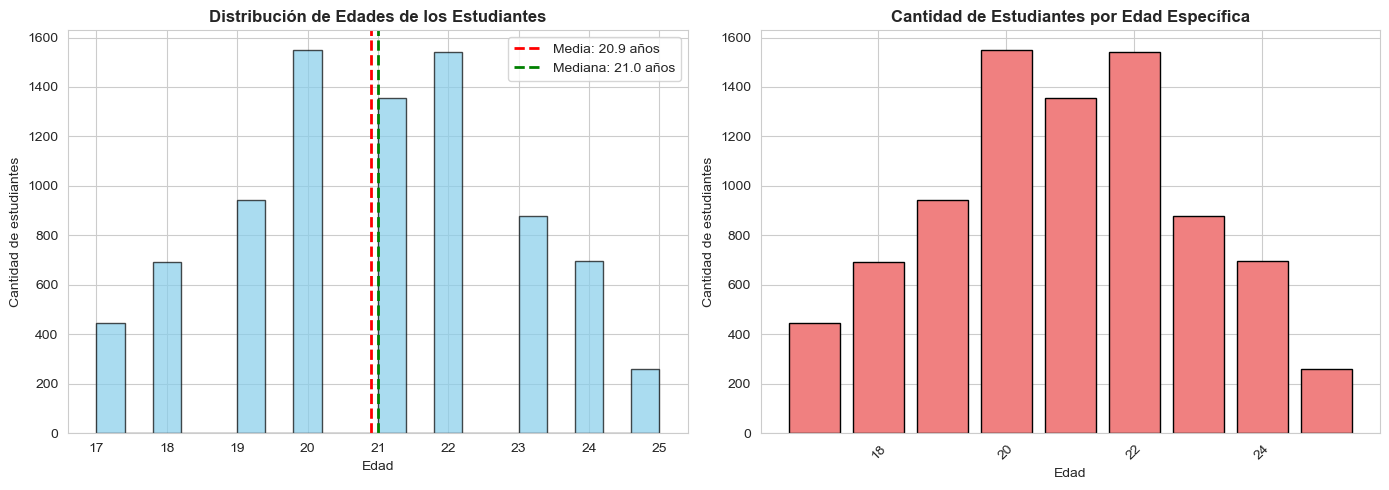

📊 ESTADÍSTICAS DE EDAD:
Total de estudiantes: 8363
Edad mínima: 17 años
Edad máxima: 25 años
Edad media: 20.9 años
Edad mediana: 21.0 años
Edad más frecuente (moda): 20 años


In [20]:
# Creación subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICO 1
axes[0].hist(df['Age'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Edades de los Estudiantes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Cantidad de estudiantes')

axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Age"].mean():.1f} años')
axes[0].axvline(df['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["Age"].median():.1f} años')
axes[0].legend()

# GRÁFICO 2
conteo_edades = df['Age'].value_counts().sort_index()

axes[1].bar(conteo_edades.index, conteo_edades.values, color='lightcoral', edgecolor='black')
axes[1].set_title('Cantidad de Estudiantes por Edad Específica', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Cantidad de estudiantes')

plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.show()

print("📊 ESTADÍSTICAS DE EDAD:")
print(f"Total de estudiantes: {len(df)}")
print(f"Edad mínima: {df['Age'].min()} años")
print(f"Edad máxima: {df['Age'].max()} años")
print(f"Edad media: {df['Age'].mean():.1f} años")
print(f"Edad mediana: {df['Age'].median():.1f} años")
print(f"Edad más frecuente (moda): {df['Age'].mode()[0]} años")

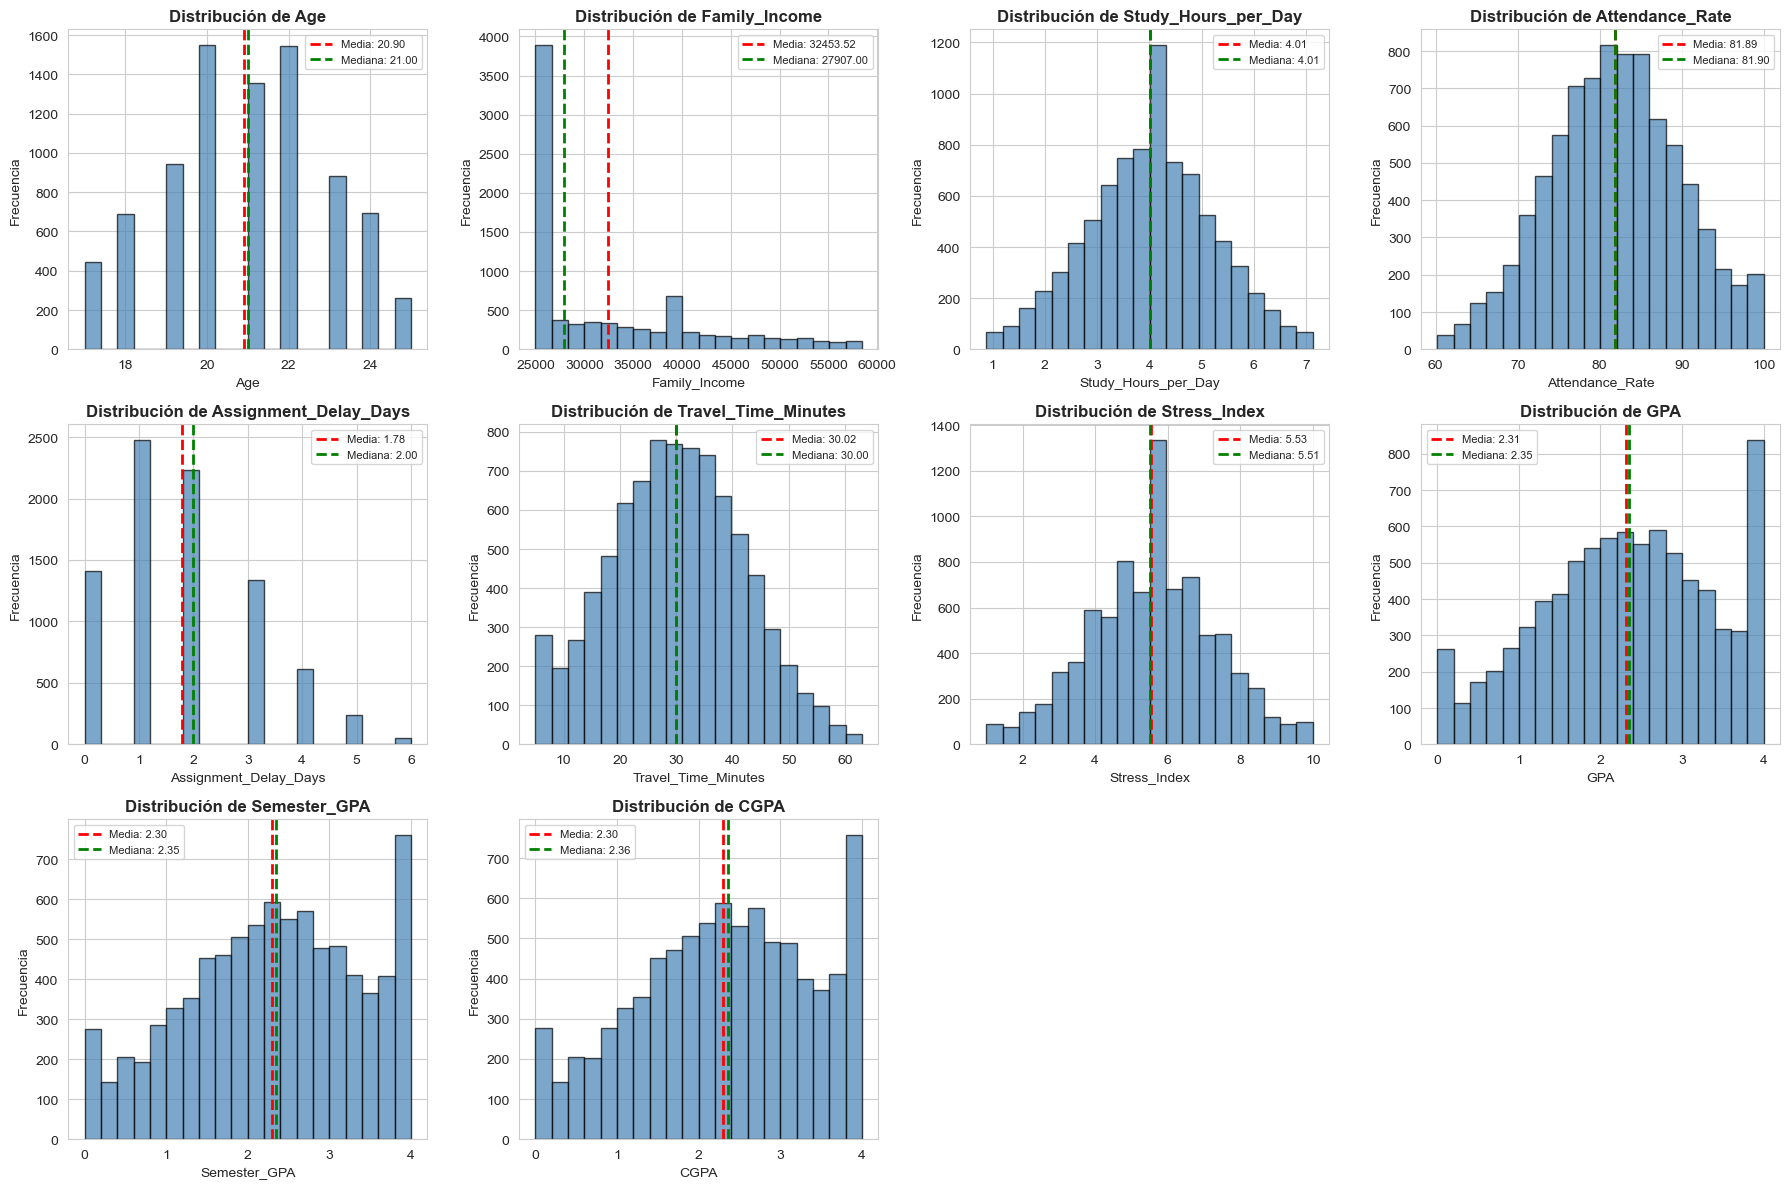

📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS:
          Age  Family_Income  Study_Hours_per_Day  Attendance_Rate  \
count  8363.0        8363.00              8363.00          8363.00   
mean     20.9       32453.52                 4.01            81.89   
std      2.02        9170.14                 1.19             8.02   
min      17.0       25000.00                 0.88            60.20   
25%      20.0       25000.00                 3.23            76.40   
50%      21.0       27907.00                 4.01            81.90   
75%      22.0       38377.25                 4.80            87.40   
max      25.0       58425.00                 7.13           100.00   

       Assignment_Delay_Days  Travel_Time_Minutes  Stress_Index      GPA  \
count                8363.00              8363.00       8363.00  8363.00   
mean                    1.78                30.02          5.53     2.31   
std                     1.31                11.79          1.73     1.05   
min           

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Lista de variables numéricas
numericas = ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 
             'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 
             'GPA', 'Semester_GPA', 'CGPA']
# Creación de subplots
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(numericas):
    # Verificar que la columna existe
    if var in df.columns:
        # Histograma 
        axes[i].hist(df[var].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribución de {var}', fontweight='bold')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Frecuencia')
        
        # Líneas de media y mediana
        media = df[var].mean()
        mediana = df[var].median()
        axes[i].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
        axes[i].axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
        axes[i].legend(fontsize=8)

for j in range(len(numericas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS:")
print(df[numericas].describe().round(2))

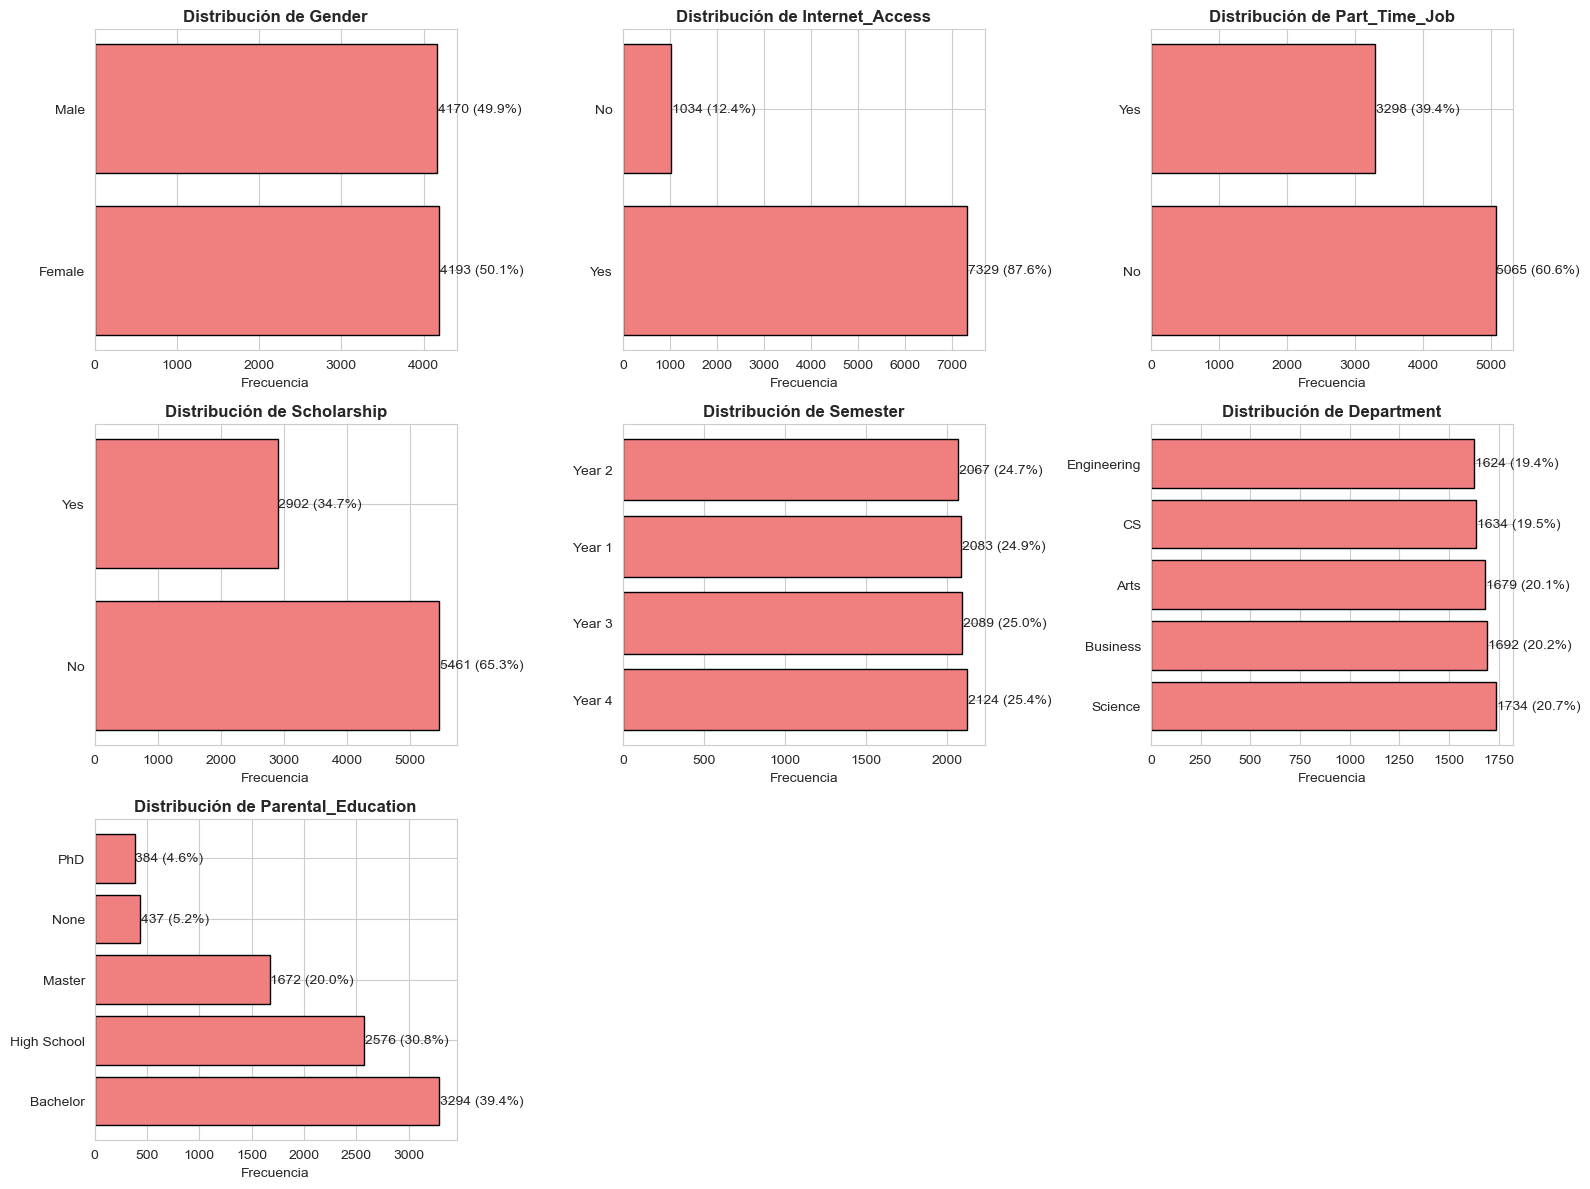


📊 FRECUENCIAS - VARIABLES CATEGÓRICAS:

Gender:
Female    4193
Male      4170
Name: Gender, dtype: int64
Porcentajes:
Female    50.1
Male      49.9
Name: Gender, dtype: float64

Internet_Access:
Yes    7329
No     1034
Name: Internet_Access, dtype: int64
Porcentajes:
Yes    87.6
No     12.4
Name: Internet_Access, dtype: float64

Part_Time_Job:
No     5065
Yes    3298
Name: Part_Time_Job, dtype: int64
Porcentajes:
No     60.6
Yes    39.4
Name: Part_Time_Job, dtype: float64

Scholarship:
No     5461
Yes    2902
Name: Scholarship, dtype: int64
Porcentajes:
No     65.3
Yes    34.7
Name: Scholarship, dtype: float64

Semester:
Year 4    2124
Year 3    2089
Year 1    2083
Year 2    2067
Name: Semester, dtype: int64
Porcentajes:
Year 4    25.4
Year 3    25.0
Year 1    24.9
Year 2    24.7
Name: Semester, dtype: float64

Department:
Science        1734
Business       1692
Arts           1679
CS             1634
Engineering    1624
Name: Department, dtype: int64
Porcentajes:
Science        20.7


In [22]:
# Variables categóricas
categoricas = ['Gender', 'Internet_Access', 'Part_Time_Job', 
               'Scholarship', 'Semester', 'Department', 'Parental_Education']
# Crear subplots
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(categoricas):
    # Contar frecuencias
    conteo = df[var].value_counts()
    
    # Gráfico de barras horizontal (mejor para categorías con nombres largos)
    axes[i].barh(conteo.index, conteo.values, color='lightcoral', edgecolor='black')
    axes[i].set_title(f'Distribución de {var}', fontweight='bold')
    axes[i].set_xlabel('Frecuencia')
    # Agregar etiquetas con valores
    for j, (cat, val) in enumerate(conteo.items()):
        axes[i].text(val + 5, j, f'{val} ({100*val/len(df):.1f}%)', va='center')

for j in range(len(categoricas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("\n📊 FRECUENCIAS - VARIABLES CATEGÓRICAS:")
for var in categoricas:
    print(f"\n{var}:")
    print(df[var].value_counts())
    print("Porcentajes:")
    print((df[var].value_counts(normalize=True) * 100).round(1))

In [23]:
# Análisis específico de Dropout
print("🎯 VARIABLE OBJETIVO - DROPOUT:")
print(df['Dropout'].value_counts())
print("\nPorcentajes:")
print((df['Student_ID'].value_counts(normalize=True) * 100).round(1))

🎯 VARIABLE OBJETIVO - DROPOUT:
0    6396
1    1967
Name: Dropout, dtype: int64

Porcentajes:
1       0.0
6696    0.0
6694    0.0
6693    0.0
6692    0.0
       ... 
3350    0.0
3349    0.0
3348    0.0
3346    0.0
9999    0.0
Name: Student_ID, Length: 8363, dtype: float64


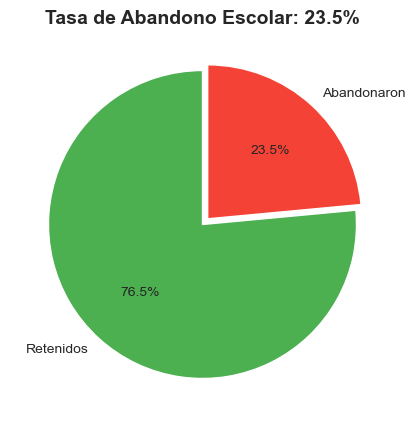

In [24]:
plt.figure(figsize=(8, 5))
colors = ['#4CAF50', '#F44336']
plt.pie(df['Dropout'].value_counts(), labels=['Retenidos', 'Abandonaron'], 
        autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05))
plt.title('Tasa de Abandono Escolar: 23.5%', fontsize=14, fontweight='bold')
plt.show()

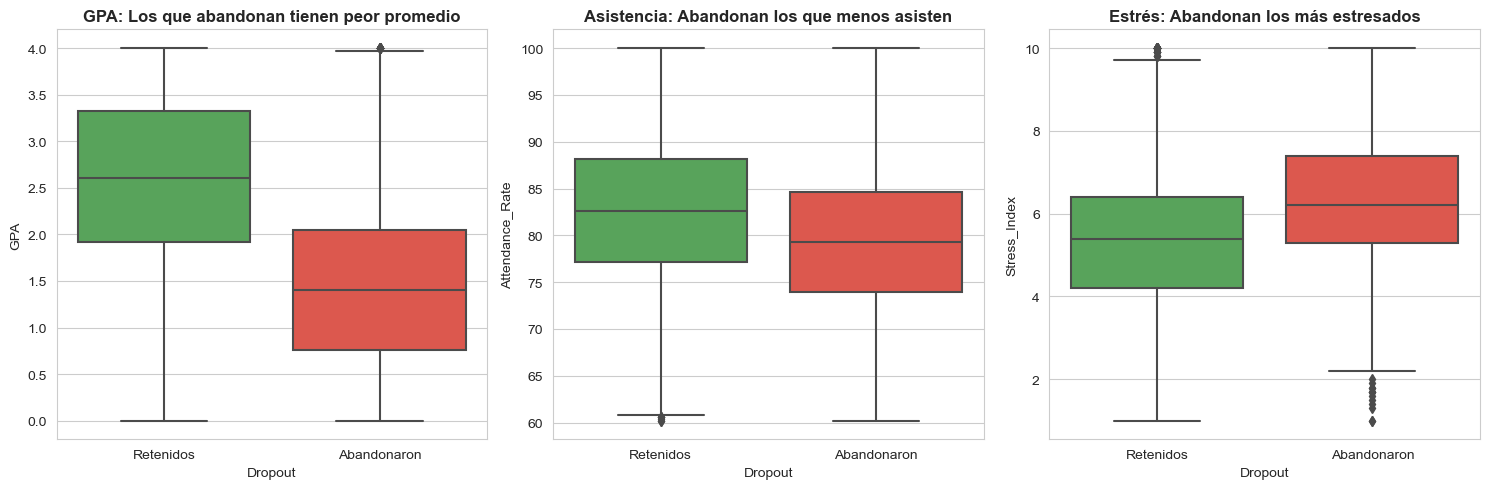

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# GPA vs Dropout
sns.boxplot(x='Dropout', y='GPA', data=df, ax=axes[0], palette=['#4CAF50', '#F44336'])
axes[0].set_title('GPA: Los que abandonan tienen peor promedio', fontweight='bold')
axes[0].set_xticklabels(['Retenidos', 'Abandonaron'])

# Asistencia vs Dropout
sns.boxplot(x='Dropout', y='Attendance_Rate', data=df, ax=axes[1], palette=['#4CAF50', '#F44336'])
axes[1].set_title('Asistencia: Abandonan los que menos asisten', fontweight='bold')
axes[1].set_xticklabels(['Retenidos', 'Abandonaron'])

# Estrés vs Dropout
sns.boxplot(x='Dropout', y='Stress_Index', data=df, ax=axes[2], palette=['#4CAF50', '#F44336'])
axes[2].set_title('Estrés: Abandonan los más estresados', fontweight='bold')
axes[2].set_xticklabels(['Retenidos', 'Abandonaron'])

plt.tight_layout()
plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_1080\2666493491.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(['No trabaja', 'Trabaja'])


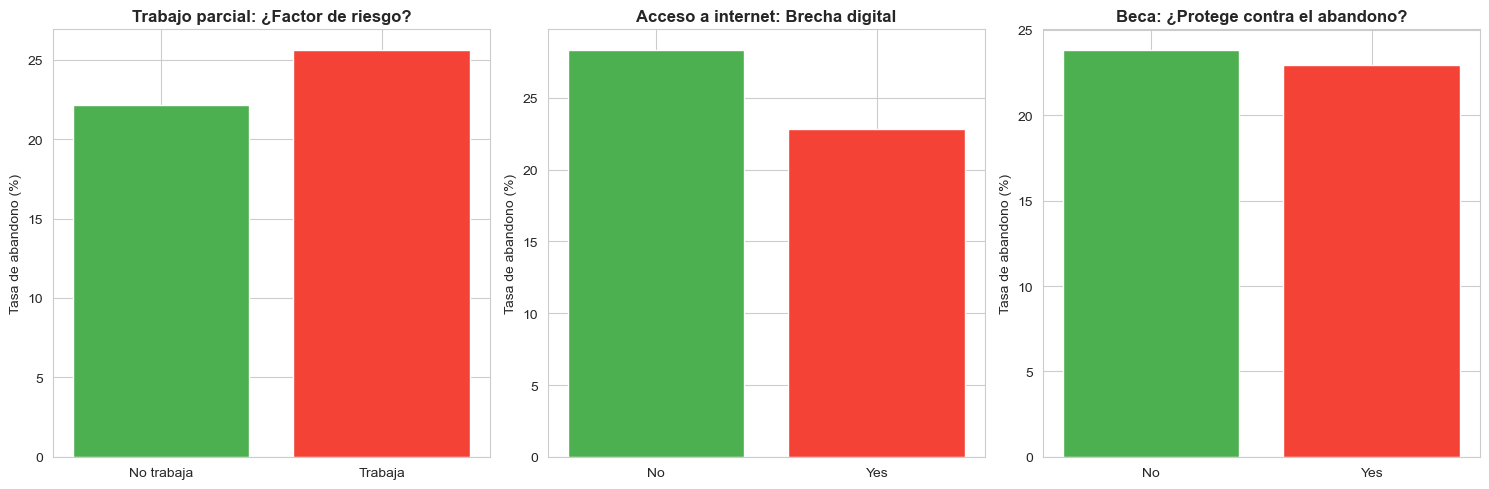

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Trabajo vs Dropout
trabajo = df.groupby('Part_Time_Job')['Dropout'].mean() * 100
axes[0].bar(trabajo.index, trabajo.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('Trabajo parcial: ¿Factor de riesgo?', fontweight='bold')
axes[0].set_ylabel('Tasa de abandono (%)')
axes[0].set_xticklabels(['No trabaja', 'Trabaja'])

# Internet vs Dropout
internet = df.groupby('Internet_Access')['Dropout'].mean() * 100
axes[1].bar(internet.index, internet.values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Acceso a internet: Brecha digital', fontweight='bold')
axes[1].set_ylabel('Tasa de abandono (%)')

# Beca vs Dropout
beca = df.groupby('Scholarship')['Dropout'].mean() * 100
axes[2].bar(beca.index, beca.values, color=['#4CAF50', '#F44336'])
axes[2].set_title('Beca: ¿Protege contra el abandono?', fontweight='bold')
axes[2].set_ylabel('Tasa de abandono (%)')

plt.tight_layout()
plt.show()

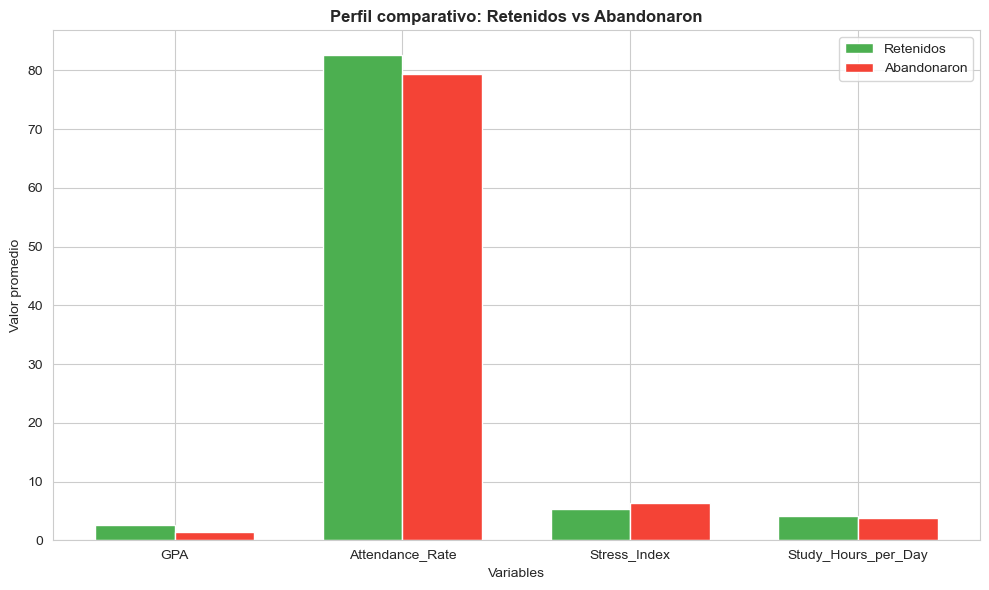

In [27]:
# Comparación de medias
retenidos = df[df['Dropout'] == 0]
abandonaron = df[df['Dropout'] == 1]

variables_clave = ['GPA', 'Attendance_Rate', 'Stress_Index', 'Study_Hours_per_Day']

x = range(len(variables_clave))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([i - width/2 for i in x], [retenidos[v].mean() for v in variables_clave], 
       width, label='Retenidos', color='#4CAF50')
ax.bar([i + width/2 for i in x], [abandonaron[v].mean() for v in variables_clave], 
       width, label='Abandonaron', color='#F44336')

ax.set_xlabel('Variables')
ax.set_ylabel('Valor promedio')
ax.set_title('Perfil comparativo: Retenidos vs Abandonaron', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(variables_clave)
ax.legend()

plt.tight_layout()
plt.show()

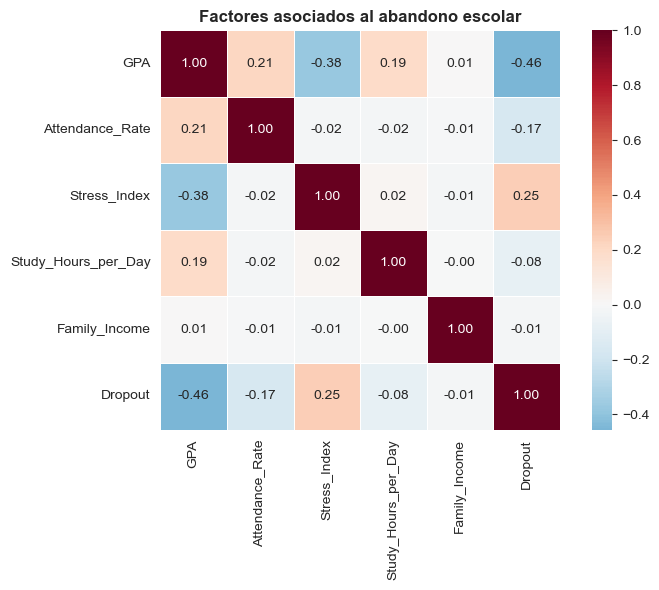

In [28]:
# Seleccionar variables clave
correlacion = df[['GPA', 'Attendance_Rate', 'Stress_Index', 'Study_Hours_per_Day', 
                  'Family_Income', 'Dropout']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Factores asociados al abandono escolar', fontweight='bold')
plt.tight_layout()
plt.show()

# Conclusiones

**La asistencia tiene una fuerte relación con el abandono escolar**

Los estudiantes con menor porcentaje de asistencia presentan mayor probabilidad de abandonar sus estudios. Esto sugiere que la asistencia es uno de los indicadores más importantes para detectar riesgo académico temprano.

**El estrés elevado afecta negativamente el rendimiento académico**

En  visualizaciones se observa que altos niveles de estrés están asociados con peores resultados académicos y mayor riesgo de abandono. El bienestar emocional parece influir directamente en el desempeño estudiantil.

**Más horas de estudio se relacionan con mejor rendimiento**

Existe una correlación positiva entre las horas de estudio diarias y el desempeño académico. Los estudiantes que dedican más tiempo al estudio muestran mejores resultados generales.

**La mayoría de los estudiantes no abandonan, pero existe un grupo importante en riesgo**

De los 8363 estudiantes analizados:
- 6396 permanecen en el sistema
- 1967 abandonaron

Esto representa aproximadamente un 23.5% de abandono, porcentaje considerable que justifica implementar estrategias de prevención.

**El acceso a internet y factores socioeconómicos podrían influir en el desempeño**

Aunque la mayoría de estudiantes tiene acceso a internet (87.6%), existe un grupo reducido sin acceso que podría presentar desventajas académicas. Además, variables como ingresos familiares y trabajo parcial pueden influir en el tiempo disponible para estudiar y en el rendimiento.

Además, como observación general del dataset:

La edad promedio de los estudiantes es de aproximadamente 21 años. Esta distribución por género es equilibrada (casi 50%-50%), por lo que no parece existir un sesgo fuerte por sexo en la muestra analizada.